läs in datan med with open (kan man göra en funktion av detta som kan återanvändas till resterande txt-filer?)
bestäm om datan ska lagras i list, tuple eller dictionary (först tuple, sen dict? Eller numpy??)
gör en återanvändbar funktion som plottar ut värdena i en graf med matplotlib.pyplot
använd matematisk formel (Pythagoras sats) för att avgöra avstånd/förhållande mellan testpunkter och och övriga punkter
om närmaste punkten närmast Pichu, klassa som Pichu, annars som Pikachu


## funktion för att rengöra datan

In [ ]:
import numpy as np


def clean_file(input_path): # function for cleaning files
    output_path = input_path.replace(".txt", "_cleaned.txt") # replace the ending of the file with _cleaned.txt instead
    pokemon_list = [] # save all cleaned data in this list

    with open(input_path) as f_read, open(output_path, "w") as f_write: # read file and write file
        text = f_read.readlines()[1:] # start reading files from row 2 with slicing operator and save in text

        for line in text: # for each element in text
            line = line.strip().replace("(", "").replace(")", "") # strip away whitespace replace all char () with nothing/none
            f_write.write(line + "\n") # write each line on new line

            split_line = line.split(",") # split line at commas
            width = float(split_line[0]) # create variable called width for index 0 in split_line and convert to float
            height = float(split_line[1]) # create variable called height for index 1 in split_line and convert to float
            pokemon_list.append((width, height)) # add width and height to pokemon_list

    return np.array(pokemon_list) # add pokemon_list to array and return it


pichu_array = clean_file("text_files/pichu.txt") # calling the function with Pichu-file
pikachu_array = clean_file("text_files/pikachu.txt") # calling the function with Pikachu-file

pichu_array
#print(pikachu_array)

[Text(0.5, 1.0, 'Pokemon sizes'),
 Text(0.5, 0, 'width in cm'),
 Text(0, 0.5, 'height in cm'),
 (0.0, 35.0),
 (0.0, 50.0)]

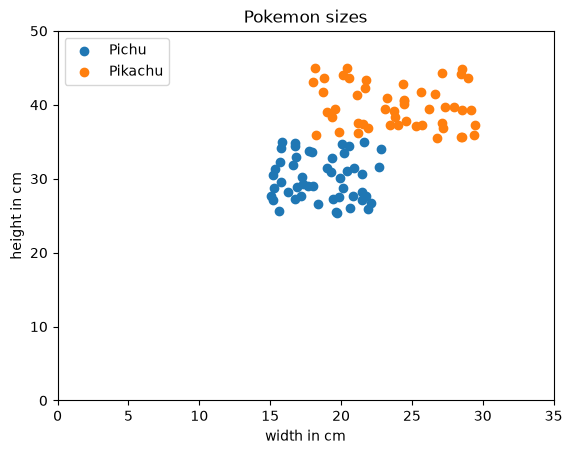

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1) # create a figure with 1 subplot
ax.scatter(pichu_array[:,0], pichu_array[:,1], label="Pichu") # plot Pichu using scatter (dots) using column 0 in all rows (x), and using column 1 in all rows (y), and add a label called Pichu
ax.scatter(pikachu_array[:,0], pikachu_array[:,1], label="Pikachu") # do the same for Pikachu
ax.legend() # Matplotlib collects labels from label= in each scatter
ax.set(title="Pokemon sizes", xlabel="width in cm", ylabel="height in cm", xlim=[0,35], ylim=[0,50]) # set title, x/ylabel, use 0-35 for x interval and 0-50 for y interval


# nästa steg är att fundera på hur vi kan göra en funktion av detta. Tänker att vi sedan kan göra en ytterligare funktion för att ta emot testpunkter samt valfri input från användaren för att kontollera typ av Pokemon